In [ ]:
"""
    学习率衰减策略介绍:
        目的:
            较之于AdaGrad, RMSProp, Adam方式, 我们可以通过 等间隔, 指定间隔, 指数等方式, 来手动控制学习率的调整.

        分类:
            等间隔学习率衰减
            指定间隔学习率衰减
            指数学习率衰减

    等间隔学习率衰减:
        step_size: 间隔的轮数, 即: 多少轮调整一次学习率.
        gamma:     学习率衰减系数, 即: lr新 = lr旧 * gamma
"""

In [3]:
# 导包
import torch
import torch.nn as nn
from torch import optim
import matplotlib.pyplot as plt

lr_list: [[0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.025], [0.025], [0.025], [0.025], [0.025], [0.025], [0.025], [0.025], [0.025], [0.025], [0.025], [0.025], [0.025], [0.025], [0.025], [0.025], [0.025], [0.025], [0.025], [0.025], [0.025], [0.025], [0.025], [0.025], [0.025], [0.025], [0.025

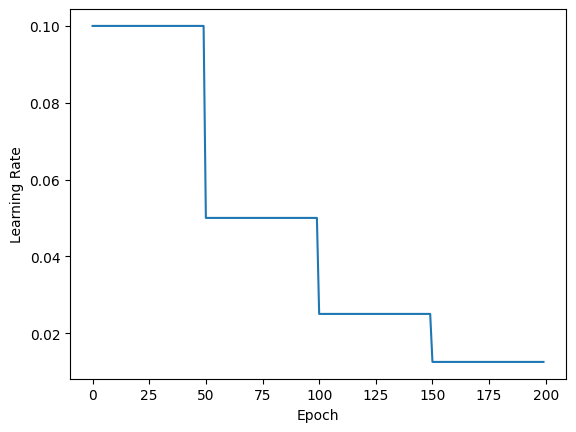

In [5]:
# 1. 定义函数, 演示: 等间隔学习率衰减
def dm01():
    # 1.定义变量，记录初始的 学习率、训练轮数、每轮训练的批次数
    lr,epochs,iteration=0.1,200,10

    # 2. 创建数据集.  y_true, x, w
    # 真实值.
    y_true = torch.tensor([0])
    # 输入特征
    x = torch.tensor([1.0], dtype=torch.float32)
    # 权重参数w, 需要自动微分(求导)
    w = torch.tensor([1.0], requires_grad=True, dtype=torch.float32)

    # 3.创建优化器对象，动量法 ——> 加速模型的收敛，减少震荡
    # 参1: 待优化的参数, 参2: 学习率, 参3: 动量系数
    optimizer=optim.SGD([w],lr=lr,momentum=0.9)

    # 4.创建学习率衰减对象
    # 思路1：创建等间隔学习率衰减对象
    # 参1: 优化器对象, 参2: 间隔的轮数(多少轮调整一次学习率), 参3: 学习率衰减系数.
    scheduler=optim.lr_scheduler.StepLR(optimizer,step_size=50,gamma=0.5)

    # 5. 创建两个列表, 分别表示: 训练轮数, 每轮训练用的学习率
    # epoch_list = [0, 1, 2, 3.... 50, 51, 52...100, 101, 101... 150, 151...199]
    # lr_list =    [0.1, 0.1, 0.1, 0.05........,0.025.........,  0.0125...]
    lr_list, epoch_list = [], []

    for epoch in range(epochs):   # epoch: 0 ~ 199
        # 7. 获取当前轮数 和 学习率, 并保存到列表中.
        epoch_list.append(epoch)
        lr_list.append(scheduler.get_last_lr())     # 获取最后的lr(learning rate, 学习率)

        # 8. 循环遍历, 每轮每批次进行训练.
        for batch in range(iteration):
            # 9. 先计算预测值, 然后基于损失函数计算损失.
            y_pred = w * x
            # 10. 计算损失, 最小二乘法.
            loss = (y_pred - y_true) ** 2
            # 11. 梯度清零 + 反向传播 + 优化器更新参数.
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # 12. 更新学习率.
        scheduler.step()

    # 13. 打印结果:
    print(f'lr_list: {lr_list}')        # [0.1, 0.1, 0.1..., 0.05........,0.025.........,  0.0125...]

    # 14. 可视化.
    # x轴: 训练的轮数, y轴: 每轮训练用的学习率
    plt.plot(epoch_list, lr_list)
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.show()

dm01()